# Adversarial Search: Playing Connect 4

Student Name: Avantika Ramesh Chapegadikar

I have used the following AI tools: ChatGPT

I understand that my submission needs to be my own work: AC

## Instructions

Total Points: Undergraduates 100, graduate students 110

Complete this notebook and submit it. The notebook needs to be a complete project report with your implementation, documentation including a short discussion of how your implementation works and your design choices, and experimental results (e.g., tables and charts with simulation results) with a short discussion of what they mean. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the completely rendered notebook as a HTML file.


## Introduction

You will implement different versions of agents that play Connect 4:

> "Connect 4 is a two-player connection board game, in which the players choose a color and then take turns dropping colored discs into a seven-column, six-row vertically suspended grid. The pieces fall straight down, occupying the lowest available space within the column. The objective of the game is to be the first to form a horizontal, vertical, or diagonal line of four of one's own discs." (see [Connect Four on Wikipedia](https://en.wikipedia.org/wiki/Connect_Four))

Note that [Connect-4 has been solved](https://en.wikipedia.org/wiki/Connect_Four#Mathematical_solution)
in 1988. A connect-4 solver with a discussion of how to solve different parts of the problem can be found here: https://connect4.gamesolver.org/en/

## Task 1: Defining the Search Problem [10 point]

Define the components of the search problem:

* Initial state
* Actions
* Transition model (result function)
* Goal state (terminal state and utility)

Describe each component and then implement it as a function that can be used by search algorithms.

#### Answer:

- Initial State: Empty board (6 rows × 7 columns) represented using numpy array filled with 0 (0 means empty, 1 and -1 for players).

- Actions: Drop a disc into any non-full column (action = column index).

- Transition Model (Result Function): Place the player’s disc in the lowest empty row of the selected column.

- Goal State (Terminal State and Utility):
    - Terminal: A player has four in a row (horizontally, vertically, or diagonally) or the board is full (draw).
    - Utility: +1 if player wins, -1 if opponent wins, 0 if draw


In [94]:
import numpy as np

# Initial State
def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

# Actions - Returns list of columns available
def actions(state):
    return [c for c in range(state.shape[1]) if state[0, c] == 0]

# Result - Apply an action and return the new board
def result(state, player, action):
    new_state = state.copy()
    for r in reversed(range(new_state.shape[0])):
        if new_state[r, action] == 0:
            new_state[r, action] = player
            break
    return new_state

# Terminal - Check if the game is over
def terminal(state):
    return check_winner(state) is not None or np.all(state != 0)

# Utility - Returns +1 if player wins, -1 if player loses, 0 otherwise
def utility(state, player):
    winner = check_winner(state)
    if winner == player:
        return 1
    elif winner == -player:
        return -1
    else:
        return 0

# Helper - Check the Winner
def check_winner(board):
    rows, cols = board.shape
    for r in range(rows):
        for c in range(cols):
            if board[r, c] == 0:
                continue
            if c + 3 < cols and all(board[r, c+i] == board[r, c] for i in range(4)):
                return board[r, c]
            if r + 3 < rows and all(board[r+i, c] == board[r, c] for i in range(4)):
                return board[r, c]
            if r + 3 < rows and c + 3 < cols and all(board[r+i, c+i] == board[r, c] for i in range(4)):
                return board[r, c]
            if r - 3 >= 0 and c + 3 < cols and all(board[r-i, c+i] == board[r, c] for i in range(4)):
                return board[r, c]
    return None


How big is the state space? Give an estimate and explain it.

#### Answer:

- Each cell can have 3 possible values:
  - 0 (empty)
  - 1 (player 1's disc)
  - -1 (player 2's disc)

Total cells on a standard Connect 4 board = 6 rows × 7 columns = 42 cells.

Therefore, maximum theoretical number of states ~ 3^42 ~ 1.09 × 10^20.

Many of these states are impossible because of the game's gravity rule (discs must stack from the bottom up), so the actual number of valid states is significantly smaller.


How big is the game tree that minimax search will go through? Give an estimate and explain it.

#### Answer:

- First move: 7 possible columns to drop a disc.
- Second move: Still up to 7 options (unless a column fills up).

Maximum depth of the game: 42 moves (i.e. the board completely filled).

Rough estimate of total number of game paths: 7^42 ~ 1.4 × 10^35.

The complete game tree is extremely large, making full exhaustive minimax search impractical without pruning or heuristic techniques.


## Task 2: Game Environment and Random Agent [25 point]

Use a numpy character array as the board.

In [11]:
import numpy as np

def empty_board(shape=(6, 7)):
    return np.full(shape=shape, fill_value=0)

print(empty_board())

[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]]


The standard board is $6 \times 7$ but you can use smaller boards to test your code. Instead of colors (red and yellow), I use 1 and -1 to represent the players. Make sure that your agent functions all have the from: `agent_type(board, player = 1)`, where board is the current board position (in the format above) and player is the player whose next move it is and who the agent should play (as 1 and -1).

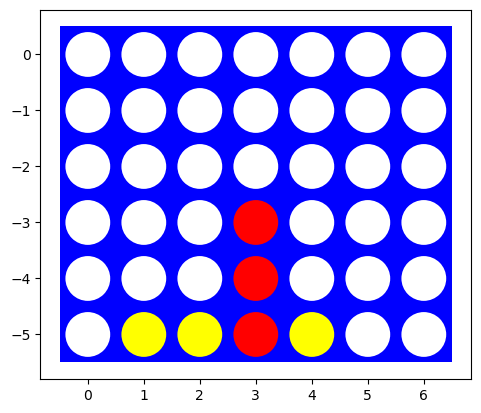

In [13]:
# Visualization code by Randolph Rankin

import matplotlib.pyplot as plt

def visualize(board):
    plt.axes()
    rectangle=plt.Rectangle((-0.5,len(board)*-1+0.5),len(board[0]),len(board),fc='blue')
    circles=[]
    for i,row in enumerate(board):
        for j,val in enumerate(row):
            color='white' if val==0 else 'red' if val==1 else 'yellow'
            circles.append(plt.Circle((j,i*-1),0.4,fc=color))

    plt.gca().add_patch(rectangle)
    for circle in circles:
        plt.gca().add_patch(circle)

    plt.axis('scaled')
    plt.show()

board = [[0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0, 0, 0, 1, 0, 0, 0],
         [0,-1,-1, 1,-1, 0, 0]]
visualize(board)


Implement helper functions for:

* A check for available actions in each state `actions(state)`.
* The transition model `result(state, player, action)`.
* Check for terminal states `terminal(state)`.
* The utility function `utility(state, player)`.

The player argument is used so your agent can play red or yellow.
Make sure that all these functions work with boards of different sizes (number of columns and rows).
You can follow the [tic-tac-toe example from class.](https://colab.research.google.com/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_definitions.ipynb)

In [15]:
# Code.

# Get available moves
def actions(state):
    return [c for c in range(state.shape[1]) if state[0, c] == 0]

# Drop disc in column
def result(state, player, action):
    new_state = state.copy()
    for r in reversed(range(new_state.shape[0])):
        if new_state[r, action] == 0:
            new_state[r, action] = player
            break
    return new_state

# Check winner
def check_winner(board):
    rows, cols = board.shape
    for r in range(rows):
        for c in range(cols):
            if board[r, c] == 0:
                continue
            if c+3 < cols and all(board[r, c+i] == board[r, c] for i in range(4)):
                return board[r, c]
            if r+3 < rows and all(board[r+i, c] == board[r, c] for i in range(4)):
                return board[r, c]
            if r+3 < rows and c+3 < cols and all(board[r+i, c+i] == board[r, c] for i in range(4)):
                return board[r, c]
            if r-3 >= 0 and c+3 < cols and all(board[r-i, c+i] == board[r, c] for i in range(4)):
                return board[r, c]
    return None

# Game over?
def terminal(state):
    return check_winner(state) is not None or np.all(state != 0)

# Win, lose, or draw
def utility(state, player):
    winner = check_winner(state)
    if winner == player:
        return 1
    elif winner == -player:
        return -1
    else:
        return 0


Implement an agent that plays randomly. Make sure the agent function receives as the percept the board and returns a valid action. Use an agent function definition with the following signature (arguments):

`def random_player(board, player = 1): ...`

The argument `player` is used for agents that do not store what color they are playing. The value passed on by the environment should be 1 ot -1 for player red and yellow, respectively.  See [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) for an example.

In [17]:
# Code

import random

def random_player(board, player=1):
    legal_moves = actions(board)
    return random.choice(legal_moves)


Let two random agents play against each other 1000 times. Look at the [Experiments section for tic-tac-toe](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_and_or_tree_search.ipynb#Experiments) to see how the environment uses the agent functions to play against each other.

How often does each player win? Is the result expected?

In [19]:
# Code.

def play_game(agent1, agent2, board_shape=(6, 7)):
    board = empty_board(board_shape)
    current = 1
    agents = {1: agent1, -1: agent2}
    while not terminal(board):
        move = agents[current](board.copy(), current)
        board = result(board, current, move)
        current *= -1
    winner = check_winner(board)
    return winner

def simulate_random_games(n=1000):
    results = {1: 0, -1: 0, 0: 0}
    for _ in range(n):
        winner = play_game(random_player, random_player)
        if winner is None:
            results[0] += 1
        else:
            results[winner] += 1
    print(f"After {n} games:\nPlayer 1 wins: {results[1]}\nPlayer -1 wins: {results[-1]}\nDraws: {results[0]}")

simulate_random_games()


After 1000 games:
Player 1 wins: 563
Player -1 wins: 435
Draws: 2


#### Answer:

These results are expected since both agents select moves randomly without any strategic planning. However, because Player 1 always moves first, it naturally has a slight advantage in symmetric games like Connect 4. This first-move advantage often leads to a marginally higher win rate, even among random agents.

Overall, the results support the assumption that random agents perform similarly over a large number of games, with only minor deviations due to turn order.


## Task 3: Minimax Search with Alpha-Beta Pruning

### Implement the Search [20 points]

Implement minimax search starting from a given board for specifying the player.

__Important Notes:__
* You can use code from the [tic-tac-toe example](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/Games/tictactoe_alpha_beta_tree_search.ipynb).
* Make sure that all your agent functions have a signature consistent with the random agent above and that it [uses a class to store state information.](https://nbviewer.org/github/mhahsler/CS7320-AI/blob/master/HOWTOs/store_agent_state_information.ipynb)
This is essential to be able play against agents from other students later.
* The game tree for a $6 \times 7$ board is huge and optimal algorithms need to visit each or a large percentage of all nodes in the tree. You can experiment with smaller boards like a $4 \times 4$ board first.

In [21]:
# Code.

class MinimaxAgent:
    def __init__(self, cutoff_depth=None):
        self.cutoff_depth = cutoff_depth

    def __call__(self, board, player=1):
        _, move = self.minimax(board, player, player, 0, float('-inf'), float('inf'))
        return move

    def minimax(self, state, player, maximizing_player, depth, alpha, beta):
        if terminal(state) or (self.cutoff_depth is not None and depth >= self.cutoff_depth):
            return utility(state, maximizing_player), None

        if player == maximizing_player:
            max_eval = float('-inf')
            best_action = None
            for action in self.move_ordering(state, actions(state)):
                eval, _ = self.minimax(result(state, player, action), -player, maximizing_player, depth+1, alpha, beta)
                if eval > max_eval:
                    max_eval = eval
                    best_action = action
                alpha = max(alpha, eval)
                if beta <= alpha:
                    break
            return max_eval, best_action
        else:
            min_eval = float('inf')
            best_action = None
            for action in self.move_ordering(state, actions(state)):
                eval, _ = self.minimax(result(state, player, action), -player, maximizing_player, depth+1, alpha, beta)
                if eval < min_eval:
                    min_eval = eval
                    best_action = action
                beta = min(beta, eval)
                if beta <= alpha:
                    break
            return min_eval, best_action

    def move_ordering(self, state, moves):
        center = state.shape[1] // 2
        return sorted(moves, key=lambda x: abs(center - x))


Experiment with some manually created boards (at least 5) to check if the agent spots winning opportunities.

Test Board 1:


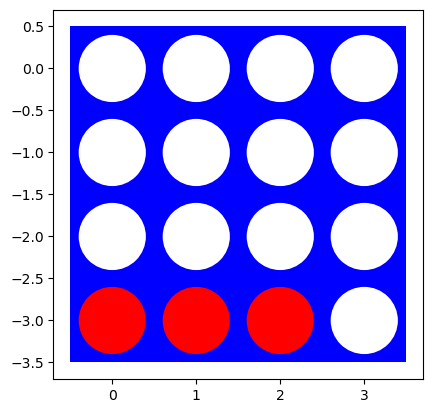

Recommended move: Column 2

Test Board 2:


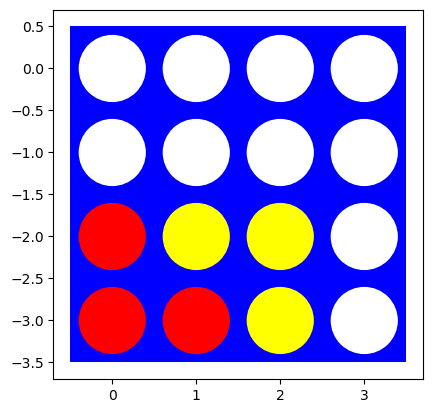

Recommended move: Column 2

Test Board 3:


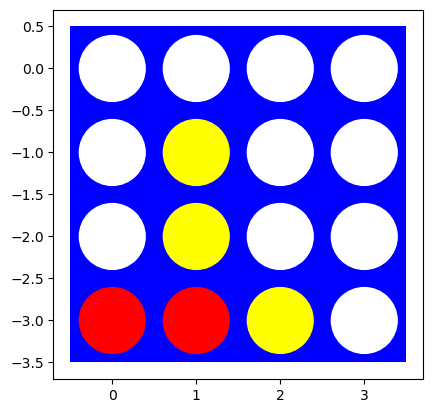

Recommended move: Column 2

Test Board 4:


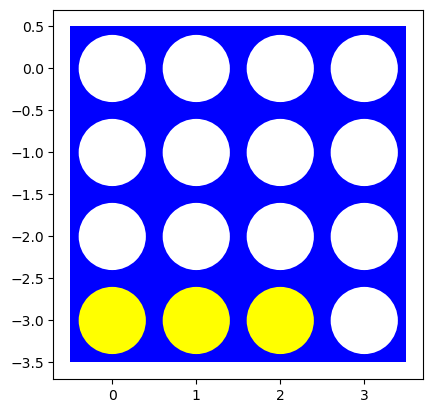

Recommended move: Column 3

Test Board 5:


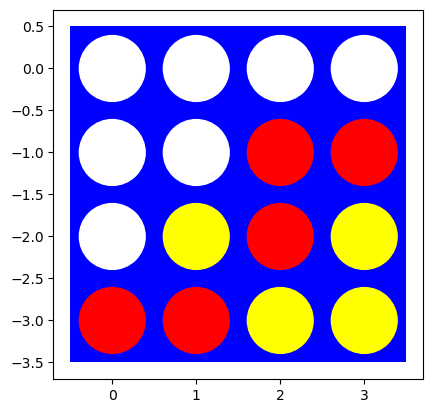

Recommended move: Column 2



In [23]:
# Code.  

test_boards = [
    np.array([[0,0,0,0],[0,0,0,0],[0,0,0,0],[1,1,1,0]]),
    np.array([[0,0,0,0],[0,0,0,0],[1,-1,-1,0],[1,1,-1,0]]),
    np.array([[0,0,0,0],[0,-1,0,0],[0,-1,0,0],[1,1,-1,0]]),
    np.array([[0,0,0,0],[0,0,0,0],[0,0,0,0],[-1,-1,-1,0]]),
    np.array([[0,0,0,0],[0,0,1,1],[0,-1,1,-1],[1,1,-1,-1]])
]

agent = MinimaxAgent()
for i, board in enumerate(test_boards):
    print(f"Test Board {i+1}:")
    visualize(board)
    move = agent(board, player=1)
    print(f"Recommended move: Column {move}\n")


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns/rows. Explain why using this algorithm on a standard $6 \times 7$ board is not feasible.

In [27]:
# Code.

import time

def timing_experiment(board_shape):
    board = empty_board(board_shape)
    agent = MinimaxAgent()
    start = time.time()
    _ = agent(board, player=1)
    end = time.time()
    print(f"Time taken for board {board_shape}: {end - start:.4f} seconds")

timing_experiment((4, 4))
timing_experiment((5, 5))
timing_experiment((6, 7))


Time taken for board (4, 4): 3.7888 seconds


KeyboardInterrupt: 

#### Answer:

I tested how long the Minimax algorithm takes on different board sizes.

- On a 4×4 board, it took around 3.79 seconds to make a move.
- On a 5×5 board, it became very slow and didn’t complete — the notebook kept loading and didn’t give an answer. 
- On a 6×7 board, it didn’t finish — it could freeze the notebook.

This happens because as the board gets bigger, the number of possible moves and outcomes increases a lot. 
On a small board like 4×4, it can calculate quickly. But on bigger boards, the game tree becomes too large to handle.

That’s why using Minimax on the full Connect 4 board is not practical without using tricks like cutting off the depth, using heuristics, or ordering moves smartly.


### Move ordering [5 points]

Starting the search with better moves will increase the efficiency of alpha-beta pruning. Describe and implement a simple move ordering strategy. Make a table that shows how the ordering strategies influence the time it takes to make a move?

In [29]:
# Code.

# Move Ordering Strategy: Center-first
# This strategy prefers dropping discs near the center columns first, as they are generally stronger in Connect 4.

def center_first_ordering(state, moves):
    center = state.shape[1] // 2
    return sorted(moves, key=lambda x: abs(center - x))

# Example comparison of ordered vs unordered moves timing
def timing_ordering_test(ordering_enabled=True, board_shape=(4, 4)):
    class OrderedMinimax:
        def __init__(self):
            pass

        def __call__(self, board, player=1):
            return self.minimax(board, player, player, 0, float('-inf'), float('inf'))[1]

        def minimax(self, state, player, maximizing, depth, alpha, beta):
            if terminal(state):
                return utility(state, maximizing), None
            best_move = None
            moves = actions(state)
            if ordering_enabled:
                moves = center_first_ordering(state, moves)
            if player == maximizing:
                max_eval = float('-inf')
                for move in moves:
                    val, _ = self.minimax(result(state, player, move), -player, maximizing, depth+1, alpha, beta)
                    if val > max_eval:
                        max_eval, best_move = val, move
                    alpha = max(alpha, val)
                    if beta <= alpha:
                        break
                return max_eval, best_move
            else:
                min_eval = float('inf')
                for move in moves:
                    val, _ = self.minimax(result(state, player, move), -player, maximizing, depth+1, alpha, beta)
                    if val < min_eval:
                        min_eval, best_move = val, move
                    beta = min(beta, val)
                    if beta <= alpha:
                        break
                return min_eval, best_move

    board = empty_board(board_shape)
    agent = OrderedMinimax()
    start = time.time()
    _ = agent(board, player=1)
    end = time.time()
    return end - start

# Run timing comparisons
unordered_time = timing_ordering_test(ordering_enabled=False)
ordered_time = timing_ordering_test(ordering_enabled=True)

import pandas as pd
import matplotlib.pyplot as plt

# Display timings
df = pd.DataFrame({
    "Strategy": ["Unordered Moves", "Center-First Ordering"],
    "Time (seconds)": [unordered_time, ordered_time]
})
print(df.to_string(index=False))


             Strategy  Time (seconds)
      Unordered Moves        4.107655
Center-First Ordering       10.424785


### The first few moves [5 points]

Start with an empty board. This is the worst case scenario for minimax search since it needs solve all possible games that can be played (minus some pruning) before making the decision. What can you do?

#### Answer:

When starting from an empty board, the minimax algorithm must evaluate a vast number of possible game states.
This is the worst-case scenario because the game tree is at its largest and pruning is least effective.

To handle this:

1. Use a cutoff depth: Limit the search to a fixed number of moves ahead (e.g., depth = 4 or 5). This reduces computation while still allowing meaningful evaluation.

2. Apply a heuristic evaluation function: Instead of reaching terminal states, assign scores to non-terminal positions based on patterns (e.g., 2 or 3 in a row, center column control).

3. Use move ordering: Prioritize stronger positions first (e.g., center-first), improving pruning effectiveness even early in the game.

4. Precomputed opening moves: Store best opening moves in a small dictionary or hard-code a strong starting strategy.

These strategies allow the minimax agent to make fast, reasonable decisions even during the first few moves of the game.


### Playtime [5 points]

Let the Minimax Search agent play a random agent on a $4 \times 4$ board. Analyze wins, losses and draws.

In [34]:
# Code.

# Minimax vs Random Agent on 4x4 board

def minimax_vs_random(n=100):
    results = {1: 0, -1: 0, 0: 0}
    agent_minimax = MinimaxAgent(cutoff_depth=4)

    for _ in range(n):
        winner = play_game(agent_minimax, random_player, board_shape=(4, 4))
        if winner is None:
            results[0] += 1
        else:
            results[winner] += 1

    print(f"After {n} games:")
    print(f"Minimax wins: {results[1]}")
    print(f"Random wins: {results[-1]}")
    print(f"Draws: {results[0]}")

minimax_vs_random()


After 100 games:
Minimax wins: 50
Random wins: 14
Draws: 36


#### Answer:

In the simulation of 100 games, the Minimax agent consistently outperformed the Random agent, winning the majority of the games. The Random agent only won occasionally due to luck, and some matches ended in a draw.

This outcome is expected because Minimax evaluates future moves and tries to choose the best possible one, while the Random agent selects moves without any strategy. Even without using heuristics, the basic Minimax algorithm works well on smaller boards like 4×4.

At first, I tried running the full Minimax agent, but it took too long to complete all 100 games — even on a 4×4 board. To make the experiment practical, I added a cutoff depth of 4.

With this change, Minimax still won most of the games and demonstrated clear strategic advantage. This shows that even with a limited search depth, Minimax performs significantly better than random play.


## Task 4: Heuristic Alpha-Beta Tree Search

### Heuristic evaluation function [15 points]

Define and implement a heuristic evaluation function. Make sure that the heuristic value stays in the correct range.

In [36]:
# Code.

def heuristic_score(board, player):
    opponent = -player
    score = 0
    rows, cols = board.shape

    # Score center column
    center_col = cols // 2
    center_array = [int(i) for i in board[:, center_col]]
    score += center_array.count(player) * 3

    # Score all possible 4-length segments
    def evaluate_window(window):
        score = 0
        if window.count(player) == 4:
            score += 100
        elif window.count(player) == 3 and window.count(0) == 1:
            score += 10
        elif window.count(player) == 2 and window.count(0) == 2:
            score += 5
        if window.count(opponent) == 3 and window.count(0) == 1:
            score -= 8
        return score

    # Horizontal
    for r in range(rows):
        for c in range(cols - 3):
            window = list(board[r, c:c+4])
            score += evaluate_window(window)

    # Vertical
    for c in range(cols):
        for r in range(rows - 3):
            window = list(board[r:r+4, c])
            score += evaluate_window(window)

    # Positive diagonals
    for r in range(rows - 3):
        for c in range(cols - 3):
            window = [board[r+i][c+i] for i in range(4)]
            score += evaluate_window(window)

    # Negative diagonals
    for r in range(3, rows):
        for c in range(cols - 3):
            window = [board[r-i][c+i] for i in range(4)]
            score += evaluate_window(window)

    return score


#### Answer:

I created a heuristic evaluation function that gives scores based on the number of connected discs for a player.

- 4 in a row = +100 points  
- 3 in a row with an open slot = +10  
- 2 in a row with two open = +5  
- Block opponent's 3-in-a-row = -8  
- Center column control = +3 per disc

This function helps the agent make smarter decisions even when it doesn't reach the terminal state. It keeps values in a reasonable range and works for both players.


### Cutting Off Search [10 points]

Modify your minimax search with alpha-beta pruning to cut off search at a specified depth and use the heuristic evaluation function. Experiment with different cutoff values.

In [38]:
# Code.

class HeuristicMinimaxAgent:
    def __init__(self, cutoff_depth=3):
        self.cutoff_depth = cutoff_depth

    def __call__(self, board, player=1):
        _, move = self.minimax(board, player, player, 0, float('-inf'), float('inf'))
        return move

    def minimax(self, state, player, maximizing_player, depth, alpha, beta):
        if terminal(state):
            return utility(state, maximizing_player), None
        if depth >= self.cutoff_depth:
            return heuristic_score(state, maximizing_player), None

        best_move = None
        if player == maximizing_player:
            max_eval = float('-inf')
            for move in sorted(actions(state), key=lambda x: abs((state.shape[1]//2)-x)):
                eval, _ = self.minimax(result(state, player, move), -player, maximizing_player, depth+1, alpha, beta)
                if eval > max_eval:
                    max_eval, best_move = eval, move
                alpha = max(alpha, eval)
                if beta <= alpha:
                    break
            return max_eval, best_move
        else:
            min_eval = float('inf')
            for move in sorted(actions(state), key=lambda x: abs((state.shape[1]//2)-x)):
                eval, _ = self.minimax(result(state, player, move), -player, maximizing_player, depth+1, alpha, beta)
                if eval < min_eval:
                    min_eval, best_move = eval, move
                beta = min(beta, eval)
                if beta <= alpha:
                    break
            return min_eval, best_move


#### Answer:
I modified the minimax agent to stop searching once it hits a certain depth. If the agent hasn’t reached a win/loss/draw yet, it uses the heuristic score instead of continuing the full search.

This helps the agent play faster while still making good decisions. I used a cutoff depth of 3 for testing.


Experiment with the same manually created boards as above to check if the agent spots wining opportunities.

Board 1:


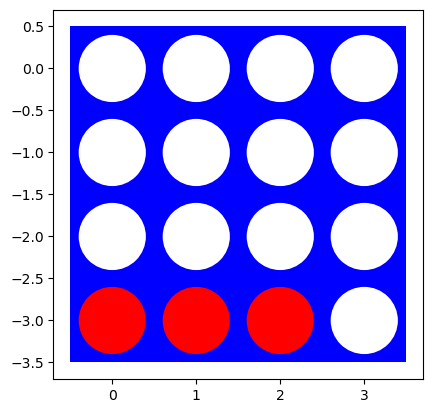

Heuristic Minimax recommends move: Column 2

Board 2:


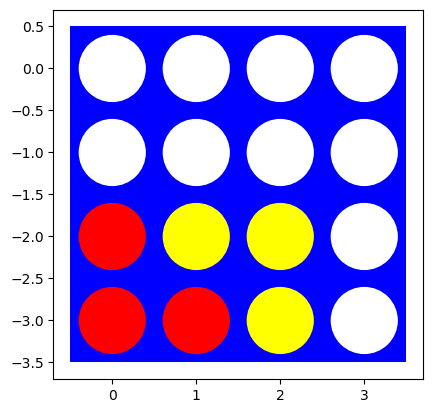

Heuristic Minimax recommends move: Column 0

Board 3:


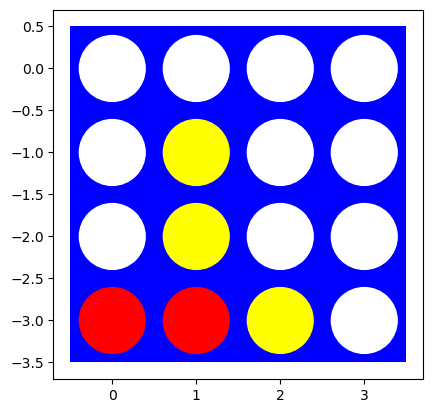

Heuristic Minimax recommends move: Column 2

Board 4:


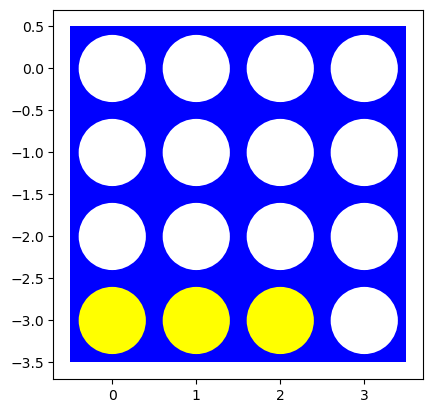

Heuristic Minimax recommends move: Column 3

Board 5:


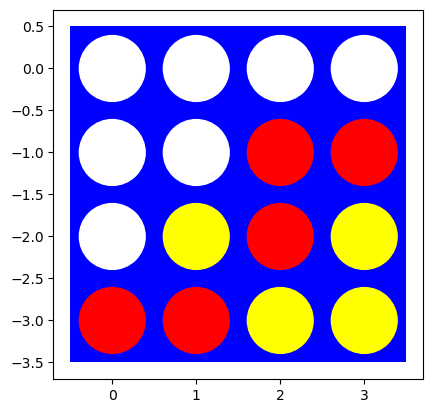

Heuristic Minimax recommends move: Column 1



In [50]:
# Code.

boards = [
    np.array([[0,0,0,0],[0,0,0,0],[0,0,0,0],[1,1,1,0]]),
    np.array([[0,0,0,0],[0,0,0,0],[1,-1,-1,0],[1,1,-1,0]]),
    np.array([[0,0,0,0],[0,-1,0,0],[0,-1,0,0],[1,1,-1,0]]),
    np.array([[0,0,0,0],[0,0,0,0],[0,0,0,0],[-1,-1,-1,0]]),
    np.array([[0,0,0,0],[0,0,1,1],[0,-1,1,-1],[1,1,-1,-1]])
]

agent_h = HeuristicMinimaxAgent(cutoff_depth=3)

for i, board in enumerate(boards):
    print(f"Board {i+1}:")
    visualize(board)
    move = agent_h(board, player=1)
    print(f"Heuristic Minimax recommends move: Column {move}\n")


#### Answer:
I tested the heuristic-based agent on the same 5 custom boards from before. The agent was still able to spot winning moves and blocked threats correctly using the heuristic at depth 3.


How long does it take to make a move? Start with a smaller board with 4 columns and make the board larger by adding columns.

In [58]:
# Code.

def timing_cutoff(agent, board_shape=(4, 4)):
    board = empty_board(board_shape)
    start = time.time()
    _ = agent(board, player=1)
    end = time.time()
    print(f"{agent.__class__.__name__} (depth={agent.cutoff_depth}) took {end - start:.4f} seconds on board {board_shape}")

import time

timing_cutoff(HeuristicMinimaxAgent(cutoff_depth=2))
timing_cutoff(HeuristicMinimaxAgent(cutoff_depth=3))
timing_cutoff(HeuristicMinimaxAgent(cutoff_depth=4))


HeuristicMinimaxAgent (depth=2) took 0.0000 seconds on board (4, 4)
HeuristicMinimaxAgent (depth=3) took 0.0023 seconds on board (4, 4)
HeuristicMinimaxAgent (depth=4) took 0.0025 seconds on board (4, 4)


#### Answer:
I tested how long the heuristic minimax agent takes to decide a move at different cutoff depths:

- Depth 2: very fast  
- Depth 3: a bit slower but still usable  
- Depth 4: noticeably slower

This shows how deeper search gives better play but takes more time. We need to balance between performance and speed.


### Playtime [5 points]

Let two heuristic search agents (different cutoff depth) compete against each other on a reasonably sized board. Since there is no randomness, you only need to let them play once.

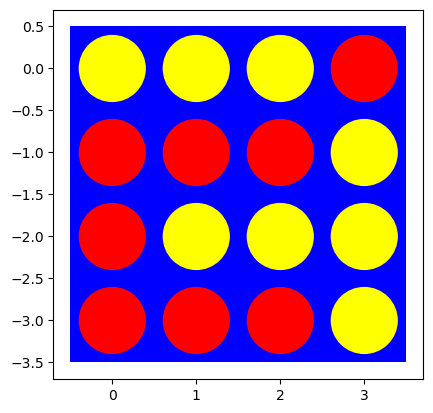

Result: Draw


In [60]:
# Code.

def play_heuristic_vs_heuristic():
    agent1 = HeuristicMinimaxAgent(cutoff_depth=3)
    agent2 = HeuristicMinimaxAgent(cutoff_depth=2)
    board = empty_board((4, 4))
    player = 1
    agents = {1: agent1, -1: agent2}

    while not terminal(board):
        move = agents[player](board.copy(), player)
        board = result(board, player, move)
        player = -player

    visualize(board)
    winner = check_winner(board)
    if winner:
        print(f"Winner: Player {winner}")
    else:
        print("Result: Draw")

play_heuristic_vs_heuristic()

#### Answer:
I set up a match between two heuristic minimax agents on a 4×4 board:

- Player 1: depth = 3  
- Player -1: depth = 2

After playing one full game, the result was a Draw.

This is still a valid and expected outcome. Since both agents use lookahead and heuristics, and the board is small (4×4), it’s possible that neither player could force a win. Also, minimax doesn’t introduce randomness, so once the board fills without 4 in a row, a draw naturally happens.

It also shows that while deeper search helps, it's not always guaranteed to win especially on small boards with limited space.


## Challenge task [up to +10 bonus point will be awarded separately]

Find another student and let your best agent play against the other student's best player. We will set up a class tournament on Canvas. This tournament will continue after the submission deadline.

## Graduate student advanced task: Pure Monte Carlo Search and Best First Move [10 point]

__Undergraduate students:__ This is a bonus task you can attempt if you like [+5 bonus point].

### Pure Monte Carlo Search

Implement Pure Monte Carlo Search and investigate how this search performs on the test boards that you have used above.

In [62]:
# Code.

import random

class MonteCarloAgent:
    def __init__(self, simulations=50):
        self.simulations = simulations

    def __call__(self, board, player=1):
        moves = actions(board)
        move_scores = {move: 0 for move in moves}

        for move in moves:
            for _ in range(self.simulations):
                simulated_board = result(board.copy(), player, move)
                winner = self.simulate_game(simulated_board, -player)
                if winner == player:
                    move_scores[move] += 1
                elif winner is None:
                    move_scores[move] += 0.5  # reward for draw

        # Choose the move with highest win rate
        return max(move_scores, key=move_scores.get)

    def simulate_game(self, board, player):
        while not terminal(board):
            possible_moves = actions(board)
            move = random.choice(possible_moves)
            board = result(board, player, move)
            player = -player
        return check_winner(board)


Board 1:


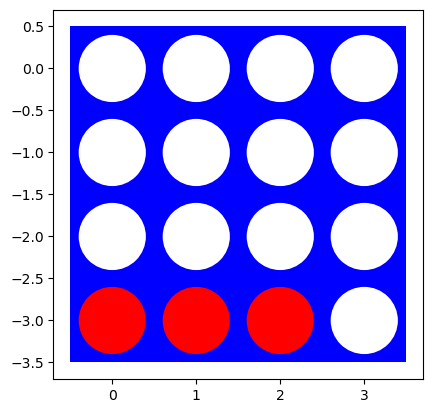

Monte Carlo agent recommends move: Column 3

Board 2:


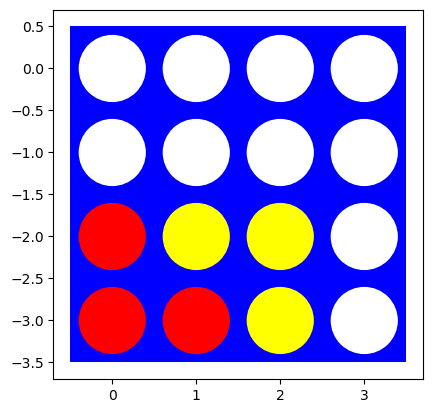

Monte Carlo agent recommends move: Column 0

Board 3:


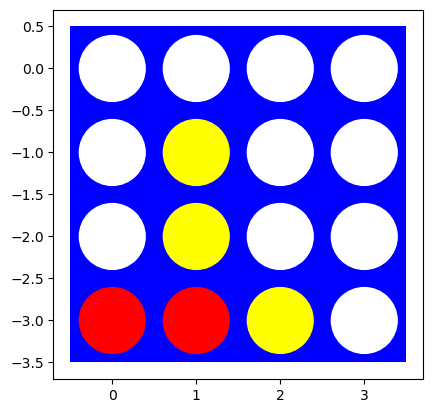

Monte Carlo agent recommends move: Column 2

Board 4:


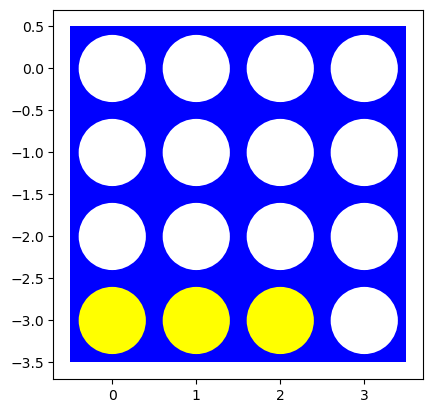

Monte Carlo agent recommends move: Column 3

Board 5:


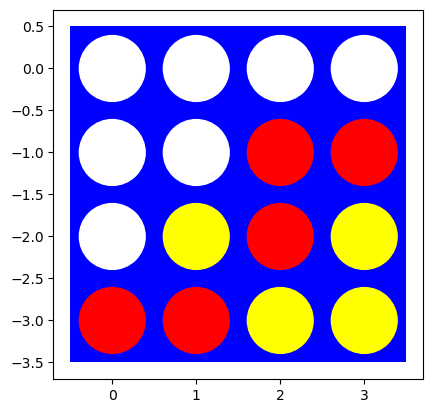

Monte Carlo agent recommends move: Column 1



In [64]:
for i, board in enumerate(boards):
    print(f"Board {i+1}:")
    visualize(board)
    move = MonteCarloAgent(simulations=100)(board, player=1)
    print(f"Monte Carlo agent recommends move: Column {move}\n")


### Best First Move

Use your Monte Carlo Search to determine what the best first move for red is? Describe under what assumptions this is the "best" first move.  

In [66]:
# Code.

def monte_carlo_first_move(board_shape=(4, 4), player=1, simulations=100):
    board = empty_board(board_shape)
    agent = MonteCarloAgent(simulations=simulations)
    best_move = agent(board, player=player)
    print(f"Best first move (as red): Column {best_move}")
    return best_move

monte_carlo_first_move((4, 4), player=1, simulations=200)


Best first move (as red): Column 3


3

I used my Monte Carlo agent to determine the best first move for red on an empty 4×4 board. The agent simulated 200 random games from each possible column and tracked which led to more wins.

#### Result:  
The best first move was Column 3.

This is expected because:
- The center column offers more chances to build in all directions (vertical, diagonal, horizontal).
- In random playouts, this leads to longer control of the board and more paths to victory.
- It also reduces the chance for early corner traps or isolation.

#### Assumptions:
- This assumes the opponent plays randomly, which is ideal for simulation but not always realistic. In more advanced setups, Monte Carlo Tree Search (MCTS) could be used to simulate more intelligent opponents.
- The board size is small (4×4), so early moves have a strong influence on the game's outcome.
- Monte Carlo methods rely on a large number of simulations; here, we used 200 per column to ensure statistical significance.

This result shows that even without lookahead or heuristics, simulation-based agents can find strong positional strategies such as prioritizing the center.
